# BIM KPI Dashboard — Construction + Facility (33 KPIs)

건설 관리 14개 + 시설 관리 17개 + 공통 2개 = **33개 KPI** 를 4개 레벨 (객체, 존, 파이프라인, 플랜트) 에서 시각화합니다.

1. Plant overview — 전체 요약 카드
2. Equipment criticality — 장비 임계도 공간 분포
3. Maintenance accessibility — 유지보수 접근성 히트맵
4. Valve isolation — 격리 구간 분석
5. Corrosion risk — 부식 리스크 (파이프라인 레벨)
6. Zone comparison — 존별 복합 KPI 비교

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from bimkg import config
from bimkg.analytics.metrics import build_physical_graph
from bimkg.analytics.zones import assign_louvain_zones
from bimkg.analytics.precedence import build_precedence_dag, find_longest_chain
from bimkg.analytics.kpi import (
    compute_equipment_criticality, compute_accessibility_index,
    compute_corrosion_risk, compute_valve_isolation,
    compute_zone_kpis, compute_pipeline_kpis, compute_plant_kpis,
)

sns.set_theme(style="whitegrid", font_scale=1.0)
FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

gold = pd.read_parquet(config.ENRICHED_OBJECTS)
adj = pd.read_parquet(config.ENRICHED_ADJACENCY_SYM)
G = build_physical_graph(gold, adj)
zone_map = assign_louvain_zones(G, resolution=3.0)
gold["zone_id"] = gold["object_id"].map(zone_map)
phys = gold[gold["graph_participant"] == True].copy()

# Compute all KPIs
crit = compute_equipment_criticality(gold, adj)
access = compute_accessibility_index(gold, adj)
corr = compute_corrosion_risk(gold)
valves = compute_valve_isolation(gold, adj)

obj_kpis = pd.DataFrame({"object_id": gold["object_id"]})
for s in [crit, access, corr]:
    df = s.reset_index(); df.columns = ["object_id", s.name]
    obj_kpis = obj_kpis.merge(df, on="object_id", how="left")
obj_kpis = obj_kpis.fillna(0)

zone_kpis = compute_zone_kpis(gold, zone_map, obj_kpis)
pipe_kpis = compute_pipeline_kpis(gold, zone_map, valves)
dag = build_precedence_dag(gold, adj, zone_col="zone_id", adjacency_tier="strong_medium")
chain = find_longest_chain(dag)
plant = compute_plant_kpis(gold, zone_kpis, pipe_kpis, len(chain))

# Merge object KPIs back to phys for plotting
phys = phys.merge(obj_kpis, on="object_id", how="left")
print("KPIs computed. Ready for visualization.")

KPIs computed. Ready for visualization.


## 1. Plant Overview

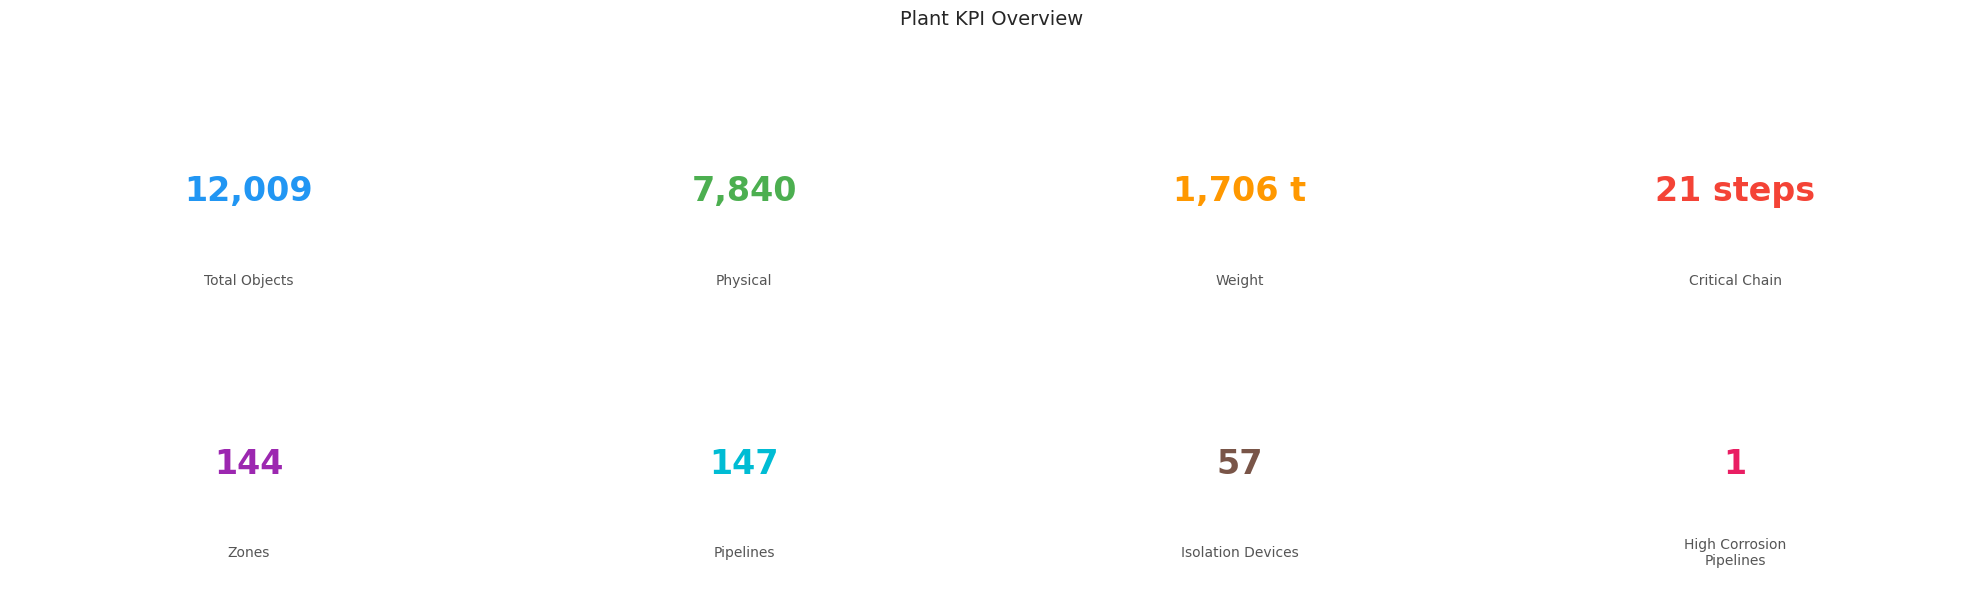

In [2]:
fig, axes = plt.subplots(2, 4, figsize=(20, 6))
cards = [
    ("Total Objects", f"{plant['total_objects']:,}", "#2196F3"),
    ("Physical", f"{plant['total_physical_objects']:,}", "#4CAF50"),
    ("Weight", f"{plant['total_weight_tonnes']:,.0f} t", "#FF9800"),
    ("Critical Chain", f"{plant['critical_chain_length']} steps", "#F44336"),
    ("Zones", f"{len(zone_kpis)}", "#9C27B0"),
    ("Pipelines", f"{len(pipe_kpis)}", "#00BCD4"),
    ("Isolation Devices", f"{len(valves)}", "#795548"),
    ("High Corrosion\nPipelines", f"{plant['high_corrosion_pipelines']}", "#E91E63"),
]
for ax, (title, value, color) in zip(axes.flat, cards):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.text(0.5, 0.55, value, ha="center", va="center", fontsize=24, fontweight="bold", color=color)
    ax.text(0.5, 0.2, title, ha="center", va="center", fontsize=10, color="#555")
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)

plt.suptitle("Plant KPI Overview", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "05_s1_plant_overview.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. Equipment Criticality — 공간 분포

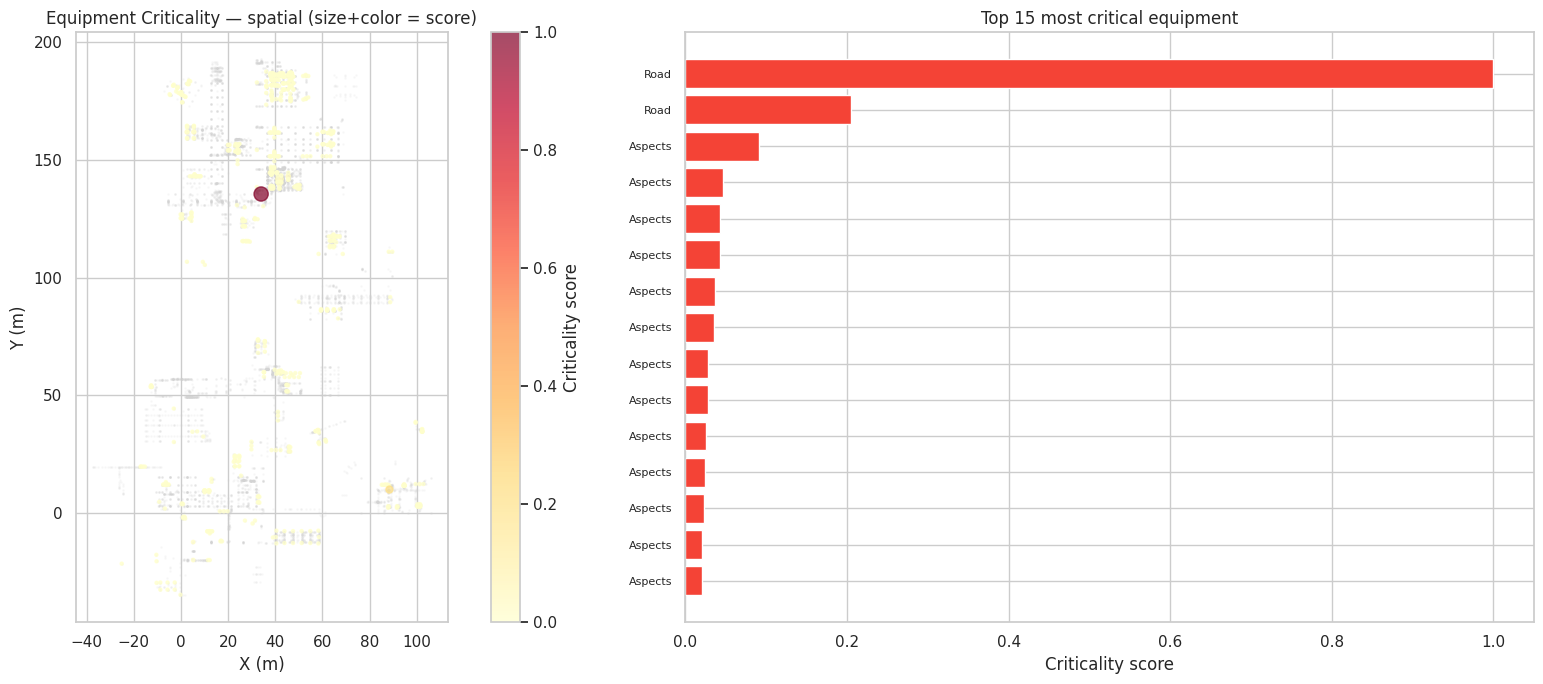

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: top view — criticality heatmap
eqp = phys[phys["refined_class"] == "Equipment"]
sc = axes[0].scatter(phys["centroid_x"], phys["centroid_y"], s=1, alpha=0.1, c="lightgray")
sc2 = axes[0].scatter(eqp["centroid_x"], eqp["centroid_y"],
                       c=eqp["equipment_criticality_score"], cmap="YlOrRd",
                       s=eqp["equipment_criticality_score"] * 100 + 5, alpha=0.7)
plt.colorbar(sc2, ax=axes[0], label="Criticality score")
axes[0].set_xlabel("X (m)"); axes[0].set_ylabel("Y (m)")
axes[0].set_title("Equipment Criticality — spatial (size+color = score)")
axes[0].set_aspect("equal")

# Right: top 15 most critical equipment
top_crit = phys[phys["refined_class"] == "Equipment"].nlargest(15, "equipment_criticality_score")
labels = [str(row["display_name"])[:30] if pd.notna(row["display_name"]) else row["object_id"][:12]
          for _, row in top_crit.iterrows()]
axes[1].barh(range(len(top_crit)), top_crit["equipment_criticality_score"], color="#F44336")
axes[1].set_yticks(range(len(top_crit)))
axes[1].set_yticklabels(labels, fontsize=8)
axes[1].set_xlabel("Criticality score")
axes[1].set_title("Top 15 most critical equipment")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES / "05_s2_equipment_criticality.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Maintenance Accessibility + Valve Isolation

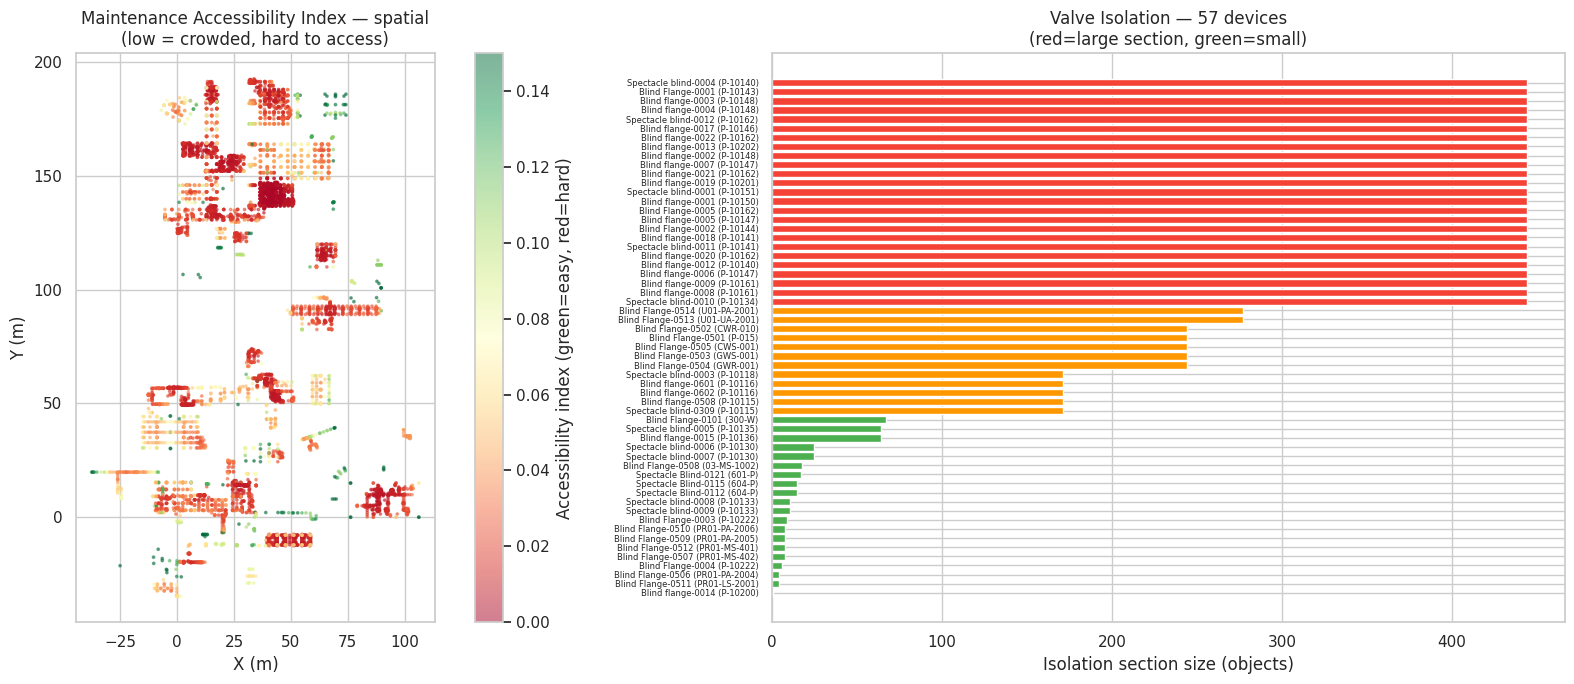

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: accessibility heatmap (top view)
sc = axes[0].scatter(phys["centroid_x"], phys["centroid_y"],
                     c=phys["maintenance_accessibility_index"], cmap="RdYlGn",
                     s=3, alpha=0.5, vmin=0, vmax=0.15)
plt.colorbar(sc, ax=axes[0], label="Accessibility index (green=easy, red=hard)")
axes[0].set_xlabel("X (m)"); axes[0].set_ylabel("Y (m)")
axes[0].set_title("Maintenance Accessibility Index — spatial\n(low = crowded, hard to access)")
axes[0].set_aspect("equal")

# Right: valve isolation sections
if not valves.empty:
    valve_data = valves.merge(gold[["object_id", "display_name", "sp3d_pipeline", "centroid_z"]], on="object_id")
    valve_data = valve_data.sort_values("isolation_section_size", ascending=False)
    labels = [f"{str(row['display_name'])[:20]} ({str(row['sp3d_pipeline'])[:12]})"
              for _, row in valve_data.iterrows()]
    colors = ["#F44336" if s > 300 else "#FF9800" if s > 100 else "#4CAF50"
              for s in valve_data["isolation_section_size"]]
    axes[1].barh(range(len(valve_data)), valve_data["isolation_section_size"], color=colors)
    axes[1].set_yticks(range(len(valve_data)))
    axes[1].set_yticklabels(labels, fontsize=6)
    axes[1].set_xlabel("Isolation section size (objects)")
    axes[1].set_title(f"Valve Isolation — {len(valve_data)} devices\n(red=large section, green=small)")
    axes[1].invert_yaxis()
else:
    axes[1].text(0.5, 0.5, "No isolation valves found", ha="center", va="center")
    axes[1].set_title("Valve Isolation")

plt.tight_layout()
plt.savefig(FIGURES / "05_s3_accessibility_isolation.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Zone Comparison — 건설 + 시설 복합 KPI

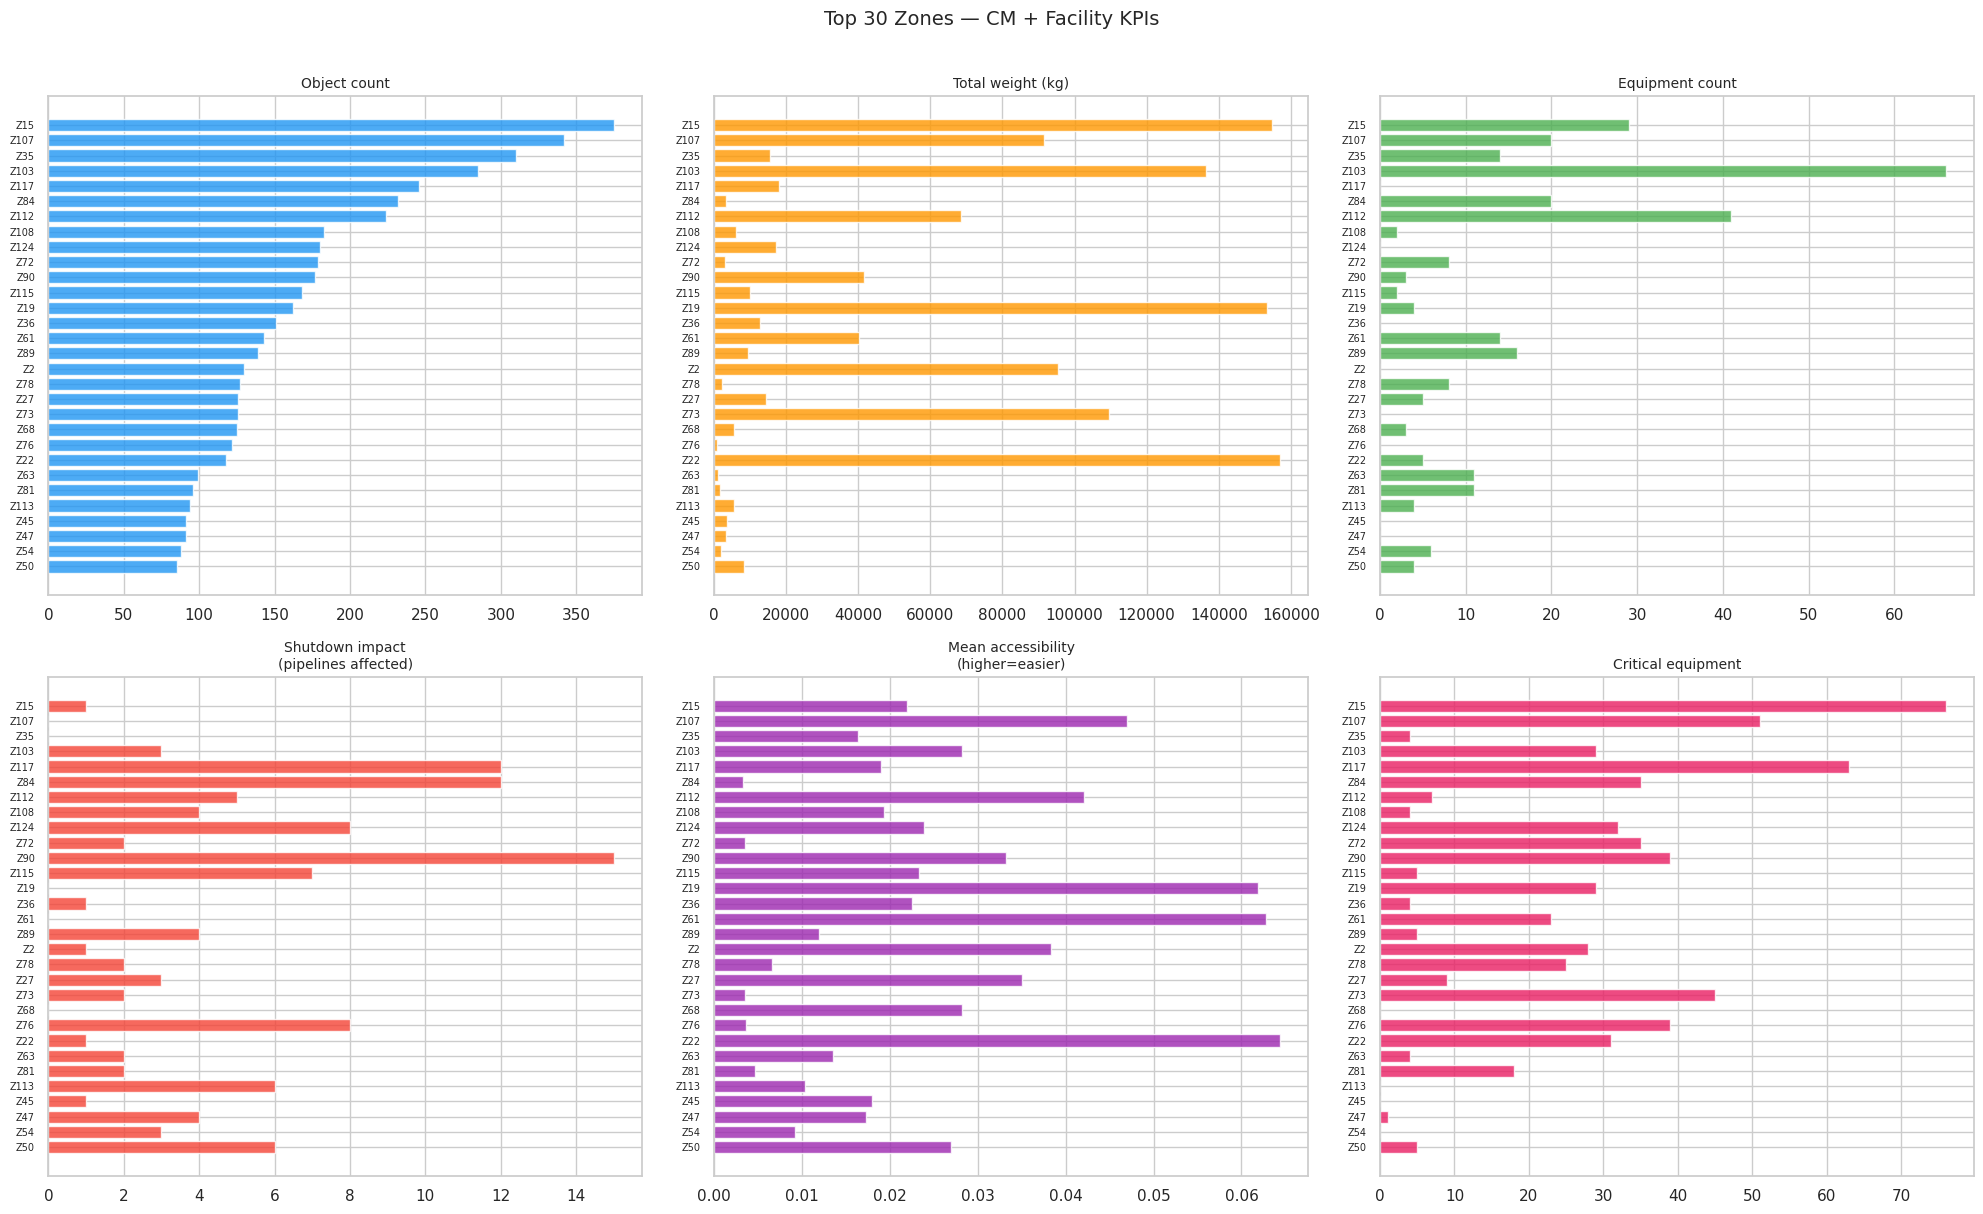

In [5]:
# Top 30 zones by object count
top30z = zone_kpis.nlargest(30, "zone_object_count")

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
zone_labels = [f"Z{int(z)}" for z in top30z.index]

metrics = [
    ("zone_object_count", "Object count", "#2196F3"),
    ("zone_total_weight_kg", "Total weight (kg)", "#FF9800"),
    ("zone_equipment_count", "Equipment count", "#4CAF50"),
    ("zone_shutdown_impact", "Shutdown impact\n(pipelines affected)", "#F44336"),
    ("zone_mean_accessibility", "Mean accessibility\n(higher=easier)", "#9C27B0"),
    ("zone_critical_equipment_count", "Critical equipment", "#E91E63"),
]

for ax, (col, title, color) in zip(axes.flat, metrics):
    vals = top30z[col].fillna(0)
    ax.barh(range(len(top30z)), vals, color=color, alpha=0.8)
    ax.set_yticks(range(len(top30z)))
    ax.set_yticklabels(zone_labels, fontsize=7)
    ax.set_title(title, fontsize=10)
    ax.invert_yaxis()

plt.suptitle("Top 30 Zones — CM + Facility KPIs", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "05_s4_zone_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Pipeline KPI Comparison — 부식 리스크 + 격리 + 크기

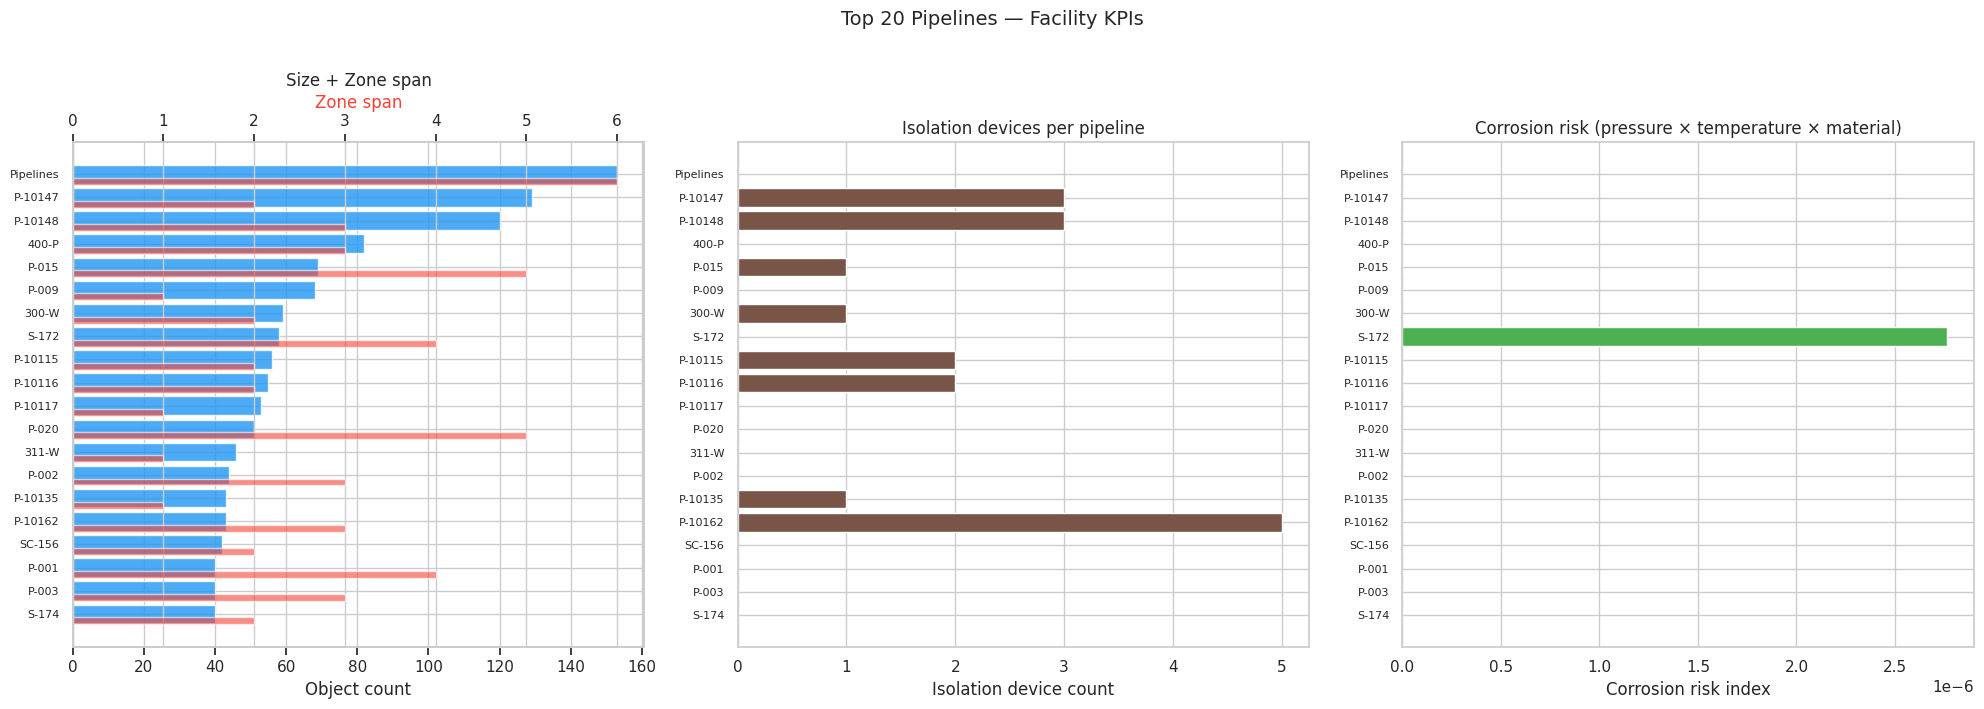

Pipelines with isolation devices: 40 / 147
Pipelines with corrosion risk > 0: 4
Max zone span: 6 zones


In [6]:
top20p = pipe_kpis.nlargest(20, "pipeline_object_count")

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
pipe_labels = [str(p)[:15] for p in top20p.index]

# Object count + zone span
ax = axes[0]
ax.barh(range(len(top20p)), top20p["pipeline_object_count"], color="#2196F3", alpha=0.8, label="Objects")
ax2 = ax.twiny()
ax2.barh([i + 0.3 for i in range(len(top20p))], top20p["pipeline_zone_span"],
         height=0.3, color="#F44336", alpha=0.6, label="Zone span")
ax.set_yticks(range(len(top20p)))
ax.set_yticklabels(pipe_labels, fontsize=8)
ax.set_xlabel("Object count"); ax2.set_xlabel("Zone span", color="#F44336")
ax.set_title("Size + Zone span")
ax.invert_yaxis()

# Valve count + isolation sections
ax = axes[1]
ax.barh(range(len(top20p)), top20p["pipeline_valve_count"].fillna(0), color="#795548")
ax.set_yticks(range(len(top20p)))
ax.set_yticklabels(pipe_labels, fontsize=8)
ax.set_xlabel("Isolation device count")
ax.set_title("Isolation devices per pipeline")
ax.invert_yaxis()

# Corrosion risk
ax = axes[2]
cr = top20p["pipeline_corrosion_risk"].fillna(0)
colors = ["#F44336" if v > 0.5 else "#FF9800" if v > 0.1 else "#4CAF50" for v in cr]
ax.barh(range(len(top20p)), cr, color=colors)
ax.set_yticks(range(len(top20p)))
ax.set_yticklabels(pipe_labels, fontsize=8)
ax.set_xlabel("Corrosion risk index")
ax.set_title("Corrosion risk (pressure × temperature × material)")
ax.invert_yaxis()

plt.suptitle("Top 20 Pipelines — Facility KPIs", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "05_s5_pipeline_kpis.png", dpi=300, bbox_inches="tight")
plt.show()

# Summary
print(f"Pipelines with isolation devices: {(pipe_kpis['pipeline_valve_count'] > 0).sum()} / {len(pipe_kpis)}")
print(f"Pipelines with corrosion risk > 0: {(pipe_kpis['pipeline_corrosion_risk'] > 0).sum()}")
print(f"Max zone span: {pipe_kpis['pipeline_zone_span'].max()} zones")